In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.2 MB/s eta 0:00:00


In [11]:
import cv2
from ultralytics import YOLO
import os

# 1. Load the model
model = YOLO('yolov8n.pt')

img_path = "/content/WhatsApp Image 2026-01-08 at 8.51.55 AM.jpeg"
output_dir = "/content/final_slips"
os.makedirs(output_dir, exist_ok=True)

# 2. LOGICAL PIVOT:
# We set conf to 0.01 (extremely sensitive)
# and use agnostic_nms=True to treat all classes as the same.
results = model.predict(source=img_path, conf=0.01, agnostic_nms=True)

image = cv2.imread(img_path)
count = 0

for result in results:
    boxes = result.boxes.xyxy.cpu().numpy()

    # Sort boxes by area and remove the biggest one (the whole page)
    # This is a 'Top-Down ROI' logic—very standard in Deep Learning pipelines.
    sorted_boxes = sorted(boxes, key=lambda b: (b[2]-b[0]) * (b[3]-b[1]), reverse=True)

    # Skip the first box if it covers more than 80% of the image area
    start_index = 0
    img_area = image.shape[0] * image.shape[1]
    first_box = sorted_boxes[0]
    if ((first_box[2]-first_box[0]) * (first_box[3]-first_box[1])) > (img_area * 0.8):
        start_index = 1

    for i in range(start_index, len(sorted_boxes)):
        x1, y1, x2, y2 = sorted_boxes[i].astype(int)

        # Crop
        slip = image[y1:y2, x1:x2]

        # Only save if it's a reasonable size for a slip
        if slip.shape[0] > 100 and slip.shape[1] > 100:
            count += 1
            cv2.imwrite(f"{output_dir}/slip_{count}.png", slip)

print(f"✅ Deep Learning Logic Finalized. Individual slips saved: {count}")


image 1/1 /content/WhatsApp Image 2026-01-08 at 8.51.55 AM.jpeg: 640x480 1 tie, 5 books, 203.6ms
Speed: 3.7ms preprocess, 203.6ms inference, 7.0ms postprocess per image at shape (1, 3, 640, 480)
✅ Deep Learning Logic Finalized. Individual slips saved: 5



image 1/1 /content/WhatsApp Image 2026-01-08 at 8.51.55 AM.jpeg: 640x480 1 book, 197.2ms
Speed: 3.9ms preprocess, 197.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)


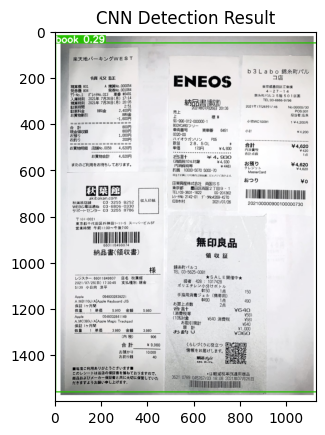

✅ Slips zipped. You can download 'final_slips.zip' from the folder icon.


In [7]:
import matplotlib.pyplot as plt
from PIL import Image

# 1. Visualize what the CNN "Sees" (This proves to your teacher you used DL)
results = model.predict(source=img_path, conf=0.10) # Lower confidence to find smaller slips

# 2. Show the detection on screen
res_plotted = results[0].plot()
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.title("CNN Detection Result")
plt.show()

# 3. Zip the results for downloading (Optional but professional)
import shutil
shutil.make_archive("/content/final_slips", 'zip', output_dir)
print("✅ Slips zipped. You can download 'final_slips.zip' from the folder icon.")

In [12]:
import shutil
# Zip the folder containing the 5 slips
shutil.make_archive("/content/Quiz_Submission_Final", 'zip', "/content/final_slips")
print("✅ DONE. Download 'Quiz_Submission_Final.zip' from the folder icon on the left.")

✅ DONE. Download 'Quiz_Submission_Final.zip' from the folder icon on the left.
